In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
# Check missing values in each column
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [3]:
# Handle missing values

# Numerical columns - fill with median
df['passengers'] = df['passengers'].fillna(df['passengers'].median())

# Categorical columns - fill with mode
categorical_columns = [
    'payment',
    'pickup_zone',
    'dropoff_zone',
    'pickup_borough',
    'dropoff_borough'
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Check missing values again
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


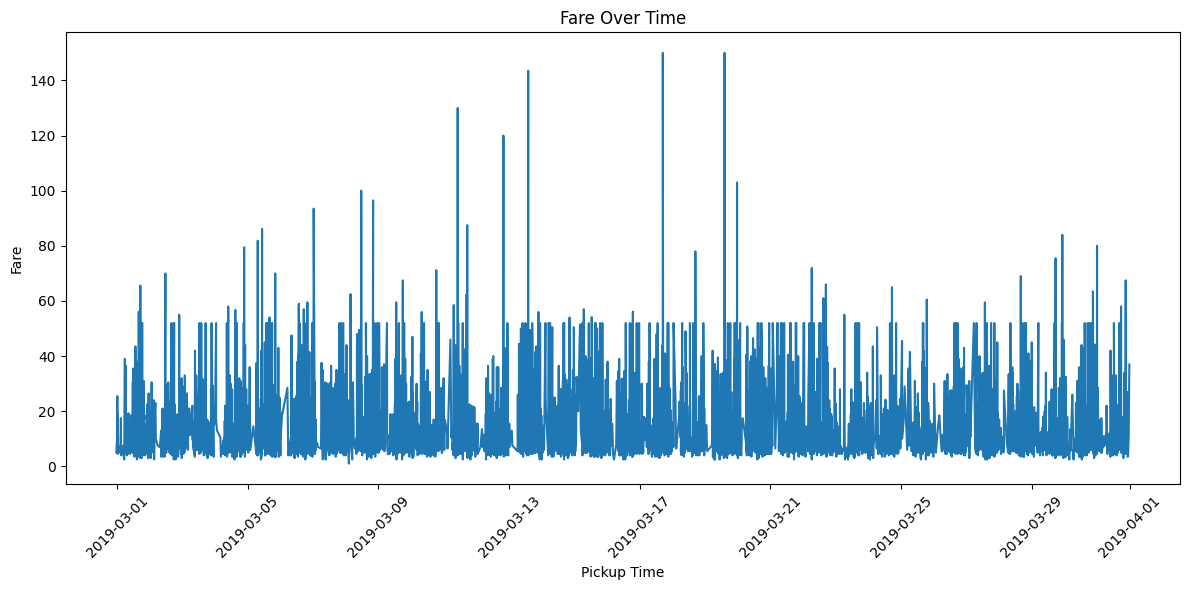

In [5]:
# Convert pickup column to datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# Sort data by pickup time
df_sorted = df.sort_values('pickup')

# Create Line Chart
plt.figure(figsize=(12, 6))
plt.plot(df_sorted['pickup'], df_sorted['fare'])

plt.title('Fare Over Time')
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

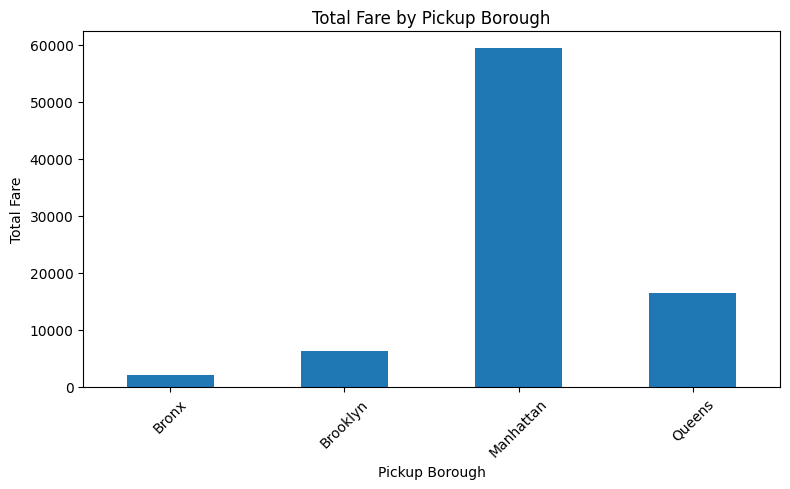

In [6]:
# Calculate total fare for each pickup borough
borough_fare = df.groupby('pickup_borough')['fare'].sum()

# Create Bar Chart
plt.figure(figsize=(8, 5))
borough_fare.plot(kind='bar')

plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

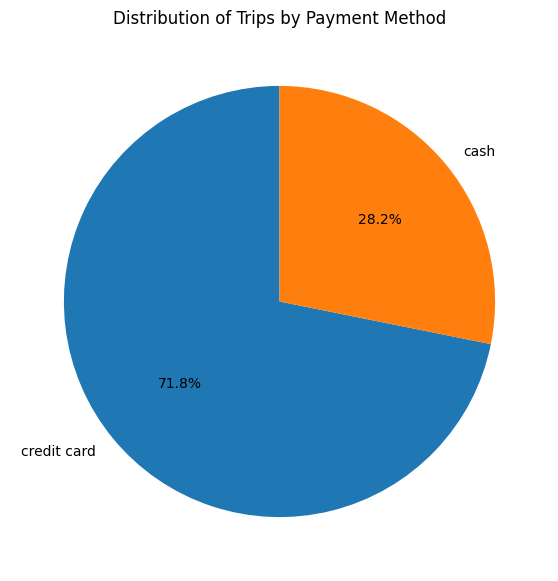

In [7]:
# Count trips by payment method
payment_counts = df['payment'].value_counts()

# Create Pie Chart
plt.figure(figsize=(7, 7))

payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Trips by Payment Method')
plt.ylabel('')

plt.show()

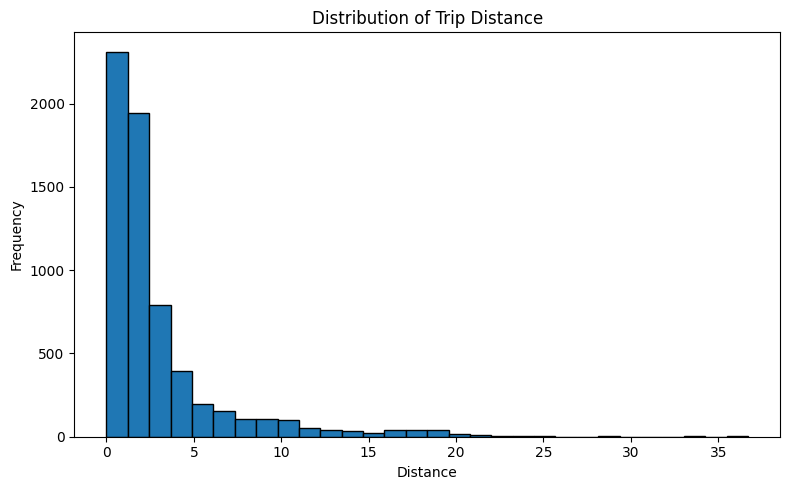

In [8]:
# Create Histogram for trip distance
plt.figure(figsize=(8, 5))

plt.hist(df['distance'], bins=30, edgecolor='black')

plt.title('Distribution of Trip Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.tight_layout()

plt.show()

<Figure size 900x600 with 0 Axes>

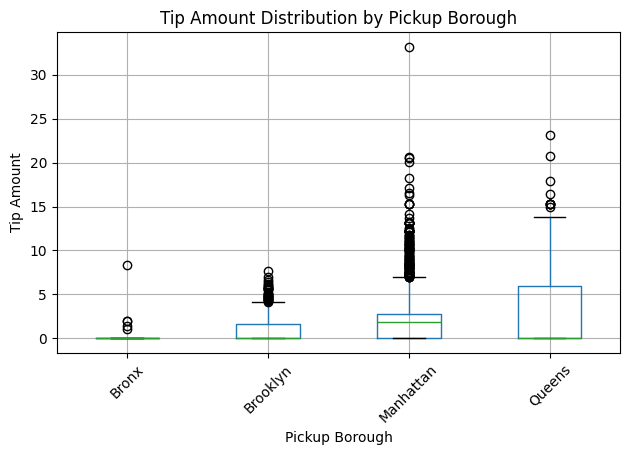

In [9]:
# Create Box Plot for tip amount by pickup borough
plt.figure(figsize=(9, 6))

df.boxplot(
    column='tip',
    by='pickup_borough'
)

plt.title('Tip Amount Distribution by Pickup Borough')
plt.suptitle('')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

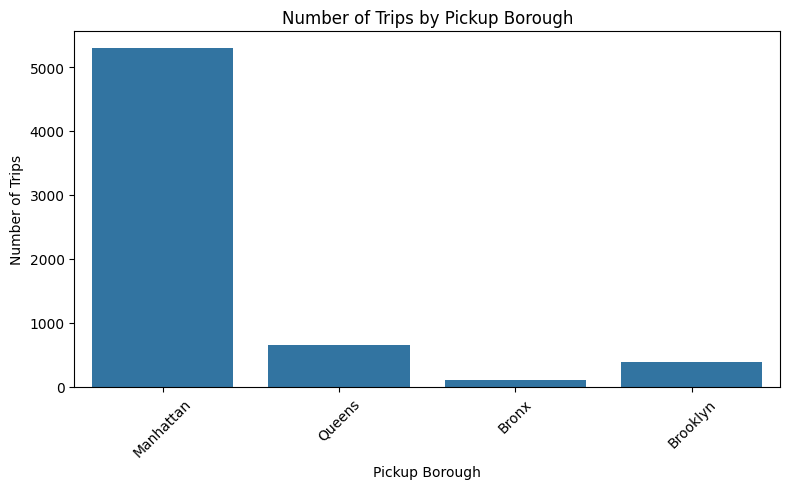

In [10]:
# Create Count Plot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='pickup_borough'
)

plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

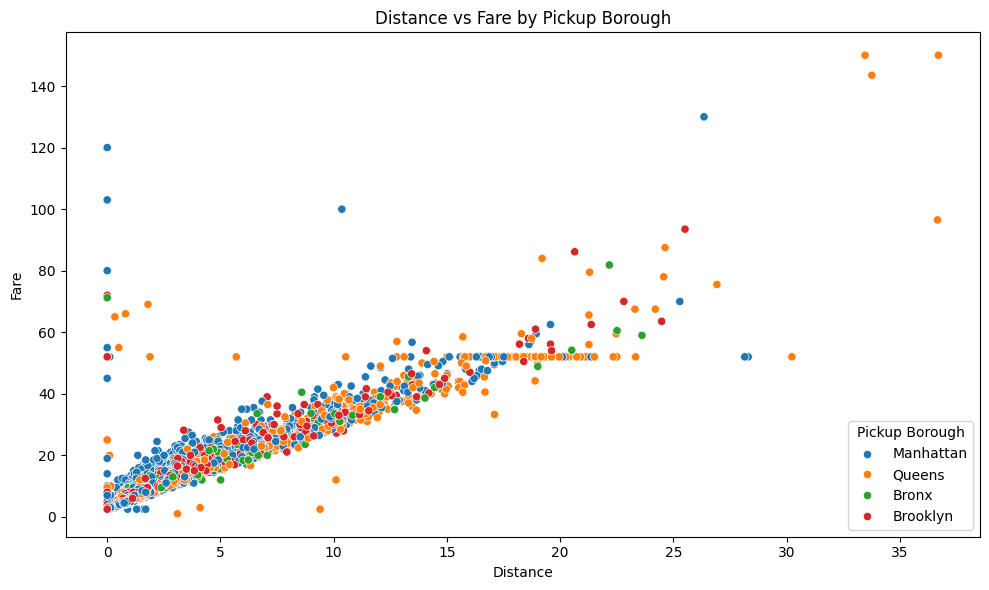

In [11]:
# Create Scatter Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.title('Distance vs Fare by Pickup Borough')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.legend(title='Pickup Borough')
plt.tight_layout()

plt.show()

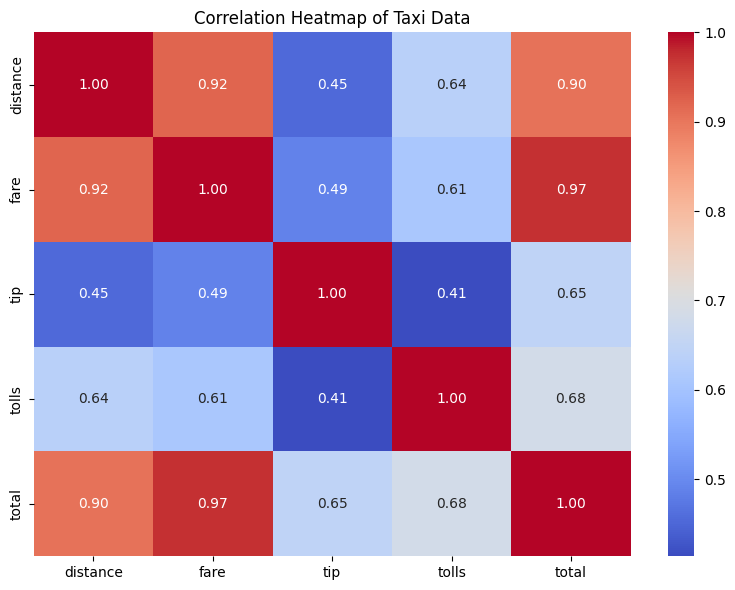

In [12]:
# Select numerical columns
numeric_data = df[['distance', 'fare', 'tip', 'tolls', 'total']]

# Calculate correlation matrix
correlation = numeric_data.corr()

# Create Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Taxi Data')
plt.tight_layout()

plt.show()

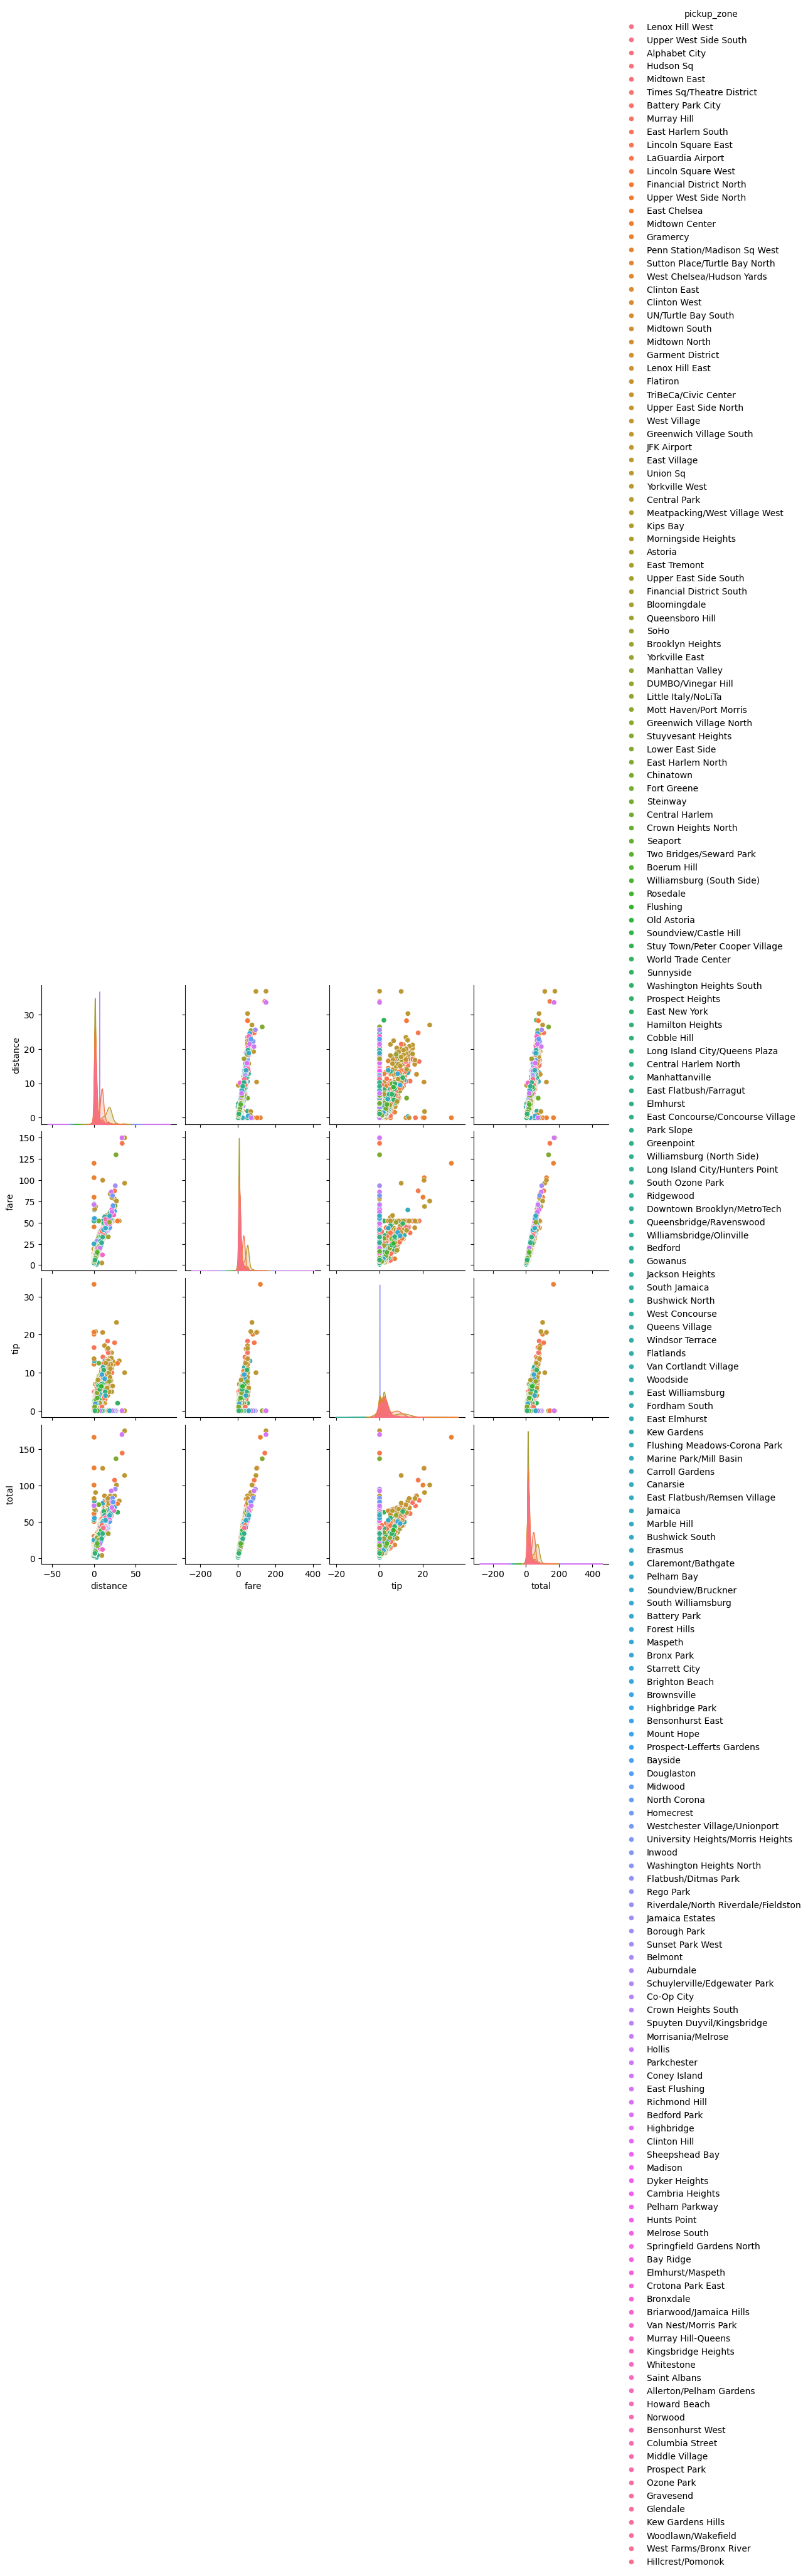

In [13]:
# Create Pair Plot
sns.pairplot(
    data=df,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone'
)

plt.show()

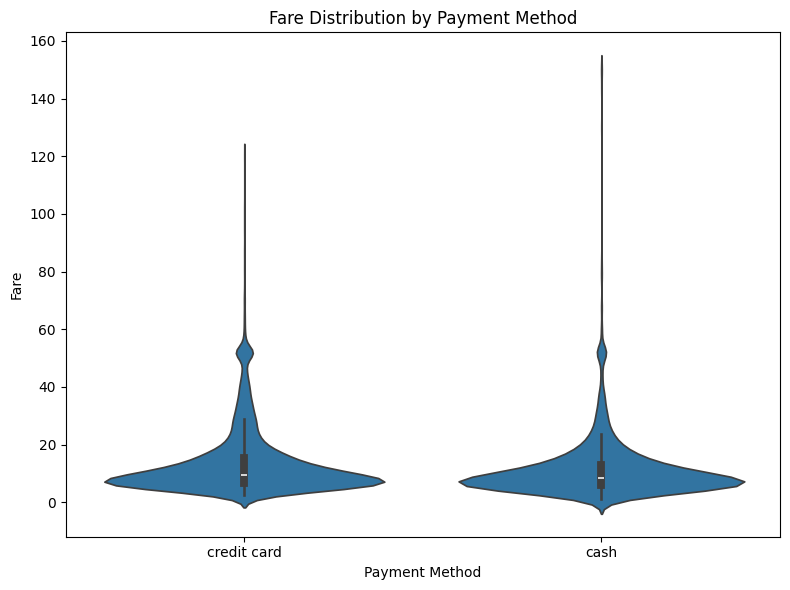

In [14]:
# Create Violin Plot
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.tight_layout()

plt.show()